<a href="https://colab.research.google.com/github/saniyaz07/bone-fracture-classification/blob/main/Bone_fracture_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

preprocessing

In [ ]:
!unzip '/content/Bone fracture dataset.zip'

Archive:  /content/Bone fracture dataset.zip
  inflating: Bone fracture dataset/Dataset/fracture/1001.png  
  inflating: Bone fracture dataset/Dataset/fracture/1005.png  
  inflating: Bone fracture dataset/Dataset/fracture/1004.png  
  inflating: Bone fracture dataset/Dataset/fracture/1003.png  
  inflating: Bone fracture dataset/Dataset/fracture/1002.png  
  inflating: Bone fracture dataset/Dataset/fracture/1.png  
  inflating: Bone fracture dataset/Dataset/fracture/1006.png  
  inflating: Bone fracture dataset/Dataset/fracture/10.png  
  inflating: Bone fracture dataset/Dataset/fracture/0.png  
  inflating: Bone fracture dataset/Dataset/fracture/100.png  
  inflating: Bone fracture dataset/Dataset/fracture/1000.png  
  inflating: Bone fracture dataset/Dataset/fracture/1007.png  
  inflating: Bone fracture dataset/Dataset/fracture/101.png  
  inflating: Bone fracture dataset/Dataset/fracture/1010.png  
  inflating: Bone fracture dataset/Dataset/fracture/1011.png  
  inflating: Bone fr

In [ ]:
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

# --- IMPORTANT: Set your folder paths here ---
# This is the directory that contains your 'fracture' and 'normal' folders.
base_dir = '/content/Bone fracture dataset/Dataset' # <-- EDIT THIS PATH IF NEEDED

fracture_dir = os.path.join(base_dir, 'fracture')
normal_dir = os.path.join(base_dir, 'normal')

# --- Define Target Image Counts ---
TARGET_FRACTURE_COUNT = 5000
TARGET_NORMAL_COUNT = 2000

# --- Count current images ---
num_fracture_images = len(os.listdir(fracture_dir))
num_normal_images = len(os.listdir(normal_dir))

print(f"Found {num_fracture_images} existing 'fracture' images.")
print(f"Found {num_normal_images} existing 'normal' images.")

# --- Define the Augmentation Pipeline ---
# These are the transformations that will be randomly applied to create new images.
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

FileNotFoundError: [Errno 2] No such file or directory: '/content/Bone fracture dataset/Dataset/fracture'

In [ ]:
def augment_images_to_target(directory, target_count, class_name):
    """
    Augments images in a given directory until a target count is reached.
    """
    num_existing_images = len(os.listdir(directory))
    images_to_generate = target_count - num_existing_images

    if images_to_generate <= 0:
        print(f"'{class_name}' folder already has {num_existing_images} images. No new images will be generated.")
        return

    print(f"Generating {images_to_generate} new images for the '{class_name}' class...")

    # Get a list of all image file paths
    all_image_paths = [os.path.join(directory, fname) for fname in os.listdir(directory)]

    generated_count = 0
    while generated_count < images_to_generate:
        # Randomly pick an image to augment
        random_image_path = np.random.choice(all_image_paths)

        # Load the image and convert it to a numpy array
        img = load_img(random_image_path)
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape) # Reshape to (1, height, width, channels)

        # Generate one new, augmented image
        for batch in datagen.flow(x, batch_size=1,
                                  save_to_dir=directory,
                                  save_prefix=f'aug_{class_name}',
                                  save_format='jpeg'):
            generated_count += 1
            break # We only want to generate one image per loop

    print(f"Finished. The '{class_name}' folder now has {len(os.listdir(directory))} images.")

In [ ]:
# Augment fracture images
augment_images_to_target(fracture_dir, TARGET_FRACTURE_COUNT, 'fracture')

# Augment normal images
augment_images_to_target(normal_dir, TARGET_NORMAL_COUNT, 'normal')

print("\n data augmentation is complete.")

Generating 108 new images for the 'fracture' class...
Finished. The 'fracture' folder now has 4974 images.
Generating 164 new images for the 'normal' class...
Finished. The 'normal' folder now has 1973 images.

 data augmentation is complete.


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# --- 1. DEFINE PARAMETERS AND PATH ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
data_dir = "/content/Bone fracture dataset/Dataset" # <-- Make sure this is the correct path

# --- 2. LOAD AND SPLIT THE DATA ---
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# --- THE FIX IS HERE ---
# Get the class names BEFORE caching and prefetching
class_names = train_ds.class_names
print(f"Class names found: {class_names}")

# Split the validation set in half to create a final test set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_ds = validation_ds.take(val_batches // 2)
val_ds = validation_ds.skip(val_batches // 2)

# --- 3. OPTIMIZE FOR PERFORMANCE ---
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# --- 4. VERIFY THE RESULTS ---
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds)}")
print("\nYour dataset is now loaded, split, and ready for model training.")

Found 6947 files belonging to 2 classes.
Using 5558 files for training.
Found 6947 files belonging to 2 classes.
Using 1389 files for validation.
Class names found: ['fracture', 'normal']
Number of training batches: 174
Number of validation batches: 22
Number of test batches: 22

Your dataset is now loaded, split, and ready for model training.


run till here only not further

end end end end

**model 1 : MobileNetV2 model**

In [ ]:
import tensorflow as tf

# Load the pre-trained MobileNetV2 model as our base
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # Exclude the final ImageNet classifier layer
    weights='imagenet'  # Use weights learned from the ImageNet dataset
)

# Freeze the convolutional base to prevent its weights from being updated
base_model.trainable = False

# Create a new model on top
inputs = tf.keras.Input(shape=(224, 224, 3))

# MobileNetV2 requires a specific preprocessing step
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# Pass the data through the frozen base model
x = base_model(x, training=False)

# Add our own custom layers for classification
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Pool the features
x = tf.keras.layers.Dropout(0.2)(x)             # Add dropout for regularization
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x) # Final prediction layer

# Create the final model
model = tf.keras.Model(inputs, outputs)

# Print a summary of the architecture
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile the model with an optimizer, loss function, and metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
EPOCHS = 10
print("\nStarting model training...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)
print("\nTraining finished!")


Starting model training...
Epoch 1/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.6619 - loss: 0.6087 - val_accuracy: 0.8423 - val_loss: 0.3941
Epoch 2/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.8260 - loss: 0.4163 - val_accuracy: 0.8920 - val_loss: 0.2975
Epoch 3/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.8783 - loss: 0.3169 - val_accuracy: 0.9212 - val_loss: 0.2429
Epoch 4/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.9040 - loss: 0.2643 - val_accuracy: 0.9387 - val_loss: 0.2066
Epoch 5/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9181 - loss: 0.2247 - val_accuracy: 0.9460 - val_loss: 0.1812
Epoch 6/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.9321 - loss: 0.2003 - val_accuracy: 0.9577 - val_loss: 0.1615
Epoch 7/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9397 - loss: 0.1814 - val_accuracy: 0.9635 - val_loss: 0.1457
Epoch 8/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.94

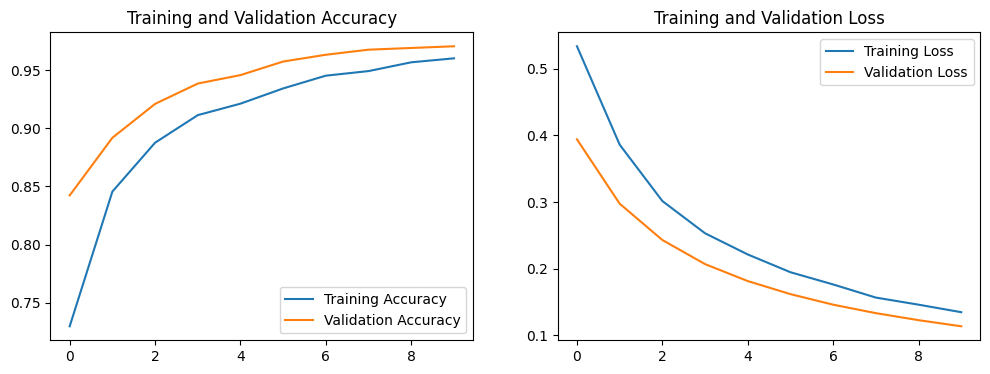


Evaluating model on the test set...
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9796 - loss: 0.1318
Test Accuracy: 97.02%


In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy and loss from the 'history' object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Evaluate the model on the test dataset
print("\nEvaluating model on the test set...")
loss, accuracy = model.evaluate(test_ds)
print(f'Test Accuracy: {accuracy*100:.2f}%')

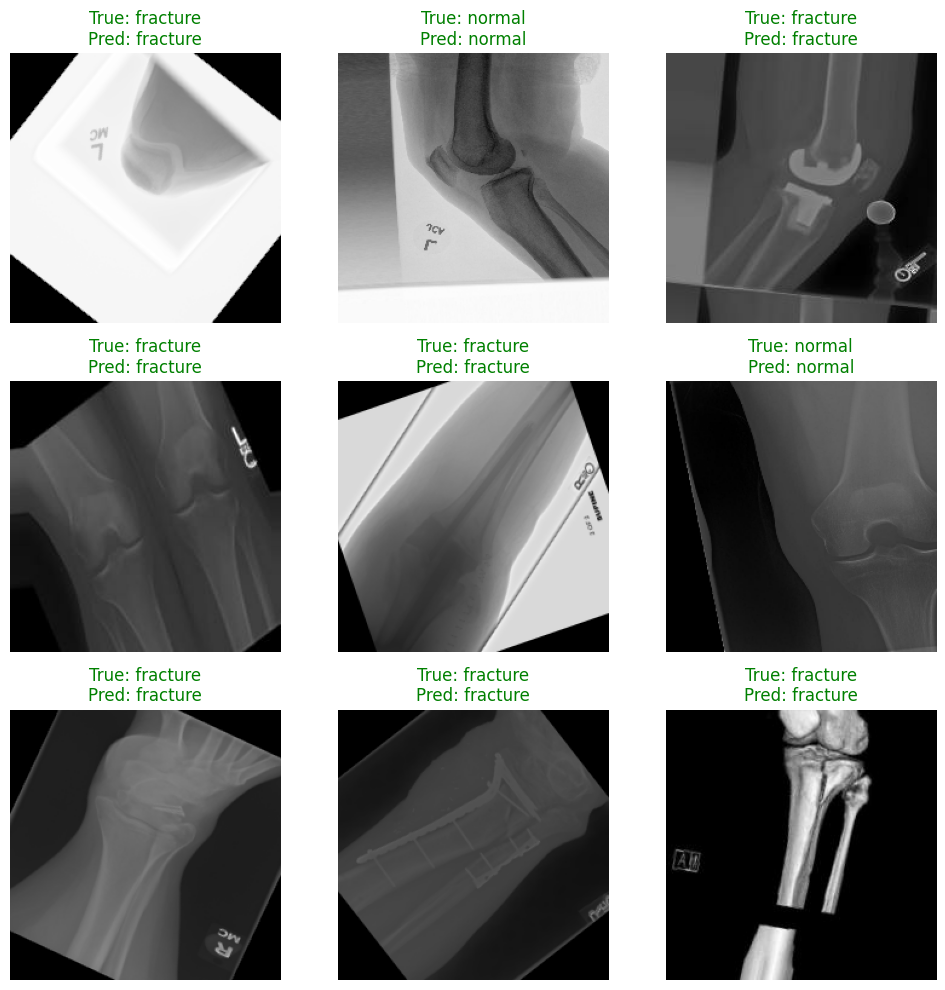

In [ ]:
# Get a batch of images from the test set
image_batch, label_batch = test_ds.as_numpy_iterator().next()
# Make predictions on that batch
predictions = model.predict_on_batch(image_batch)

# Convert probabilities (e.g., 0.98) to class names ('fracture' or 'normal')
predicted_classes = (predictions > 0.5).astype(int)

# Show the images, their true labels, and the predicted labels
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].astype("uint8"))

    true_label_index = int(label_batch[i])
    predicted_label_index = predicted_classes[i][0]

    true_label = class_names[true_label_index]
    predicted_label = class_names[predicted_label_index]

    # Set title color to green for correct prediction, red for incorrect
    title_color = 'green' if predicted_label == true_label else 'red'

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Save the entire model to a single HDF5 file.
model.save('MobileNetV2 model.h5')

print("Model saved successfully as 'MobileNetV2 model.h5'")

Model saved successfully as 'MobileNetV2 model.h5'


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Classification Report:
              precision    recall  f1-score   support

    fracture       0.98      0.98      0.98       499
      normal       0.96      0.94      0.95       205

    accuracy         

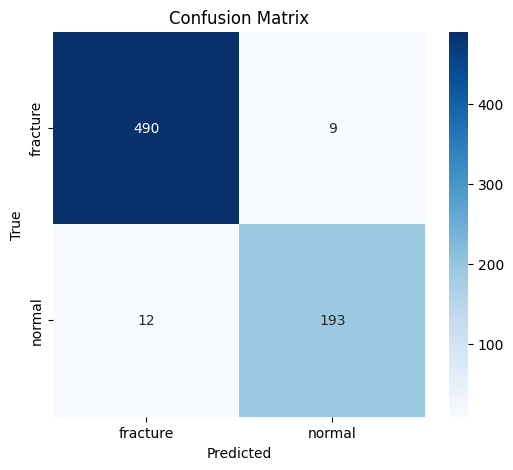

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Get all the true labels and predictions from the entire test set
y_true = []
y_pred = []

for images, labels in test_ds:
  y_true.extend(labels.numpy().flatten())
  preds = model.predict(images)
  y_pred.extend((preds > 0.5).astype(int).flatten())

# Print the classification report (shows precision, recall, f1-score)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Display the confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**model 2 : EfficientNetB0 model**

In [ ]:
# Load the pre-trained EfficientNetB0 model
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze the base model
base_model.trainable = False

# Create your new model on top
inputs = tf.keras.Input(shape=(224, 224, 3))
# EfficientNet has its preprocessing built into the model, but rescaling is good practice
x = tf.keras.layers.Rescaling(1./255)(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
import tensorflow as tf

# --- Step 1: Re-build the Model with the Correct Preprocessing ---
# Load the pre-trained EfficientNetB0 model
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Keep the main weights frozen

# Create your new model on top
inputs = tf.keras.Input(shape=(224, 224, 3))

# --- THE FIX IS HERE ---
# Use the dedicated preprocessing function for EfficientNet
x = tf.keras.applications.efficientnet.preprocess_input(inputs)

# Call the base model with training=True to keep batch norm adaptive
x = base_model(x, training=True)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)


# --- Step 2: Compile with the Standard Learning Rate ---
print("Compiling model with correct preprocessing...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Compilation complete.")


# --- Step 3: Start Training ---
EPOCHS = 10
print("\nStarting model training...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)
print("\nTraining finished!")

Compiling model with correct preprocessing...
Compilation complete.

Starting model training...
Epoch 1/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - accuracy: 0.7813 - loss: 0.4402 - val_accuracy: 0.9810 - val_loss: 0.1485
Epoch 2/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 439s 3s/step - accuracy: 0.9674 - loss: 0.1505 - val_accuracy: 0.9912 - val_loss: 0.0866
Epoch 3/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 475s 3s/step - accuracy: 0.9814 - loss: 0.0968 - val_accuracy: 0.9927 - val_loss: 0.0624
Epoch 4/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 439s 3s/step - accuracy: 0.9815 - loss: 0.0754 - val_accuracy: 0.9956 - val_loss: 0.0503
Epoch 5/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 439s 3s/step - accuracy: 0.9911 - loss: 0.0565 - val_accuracy: 0.9971 - val_loss: 0.0413
Epoch 6/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 474s 3s/step - accuracy: 0.9940 - loss: 0.0492 - val_accuracy: 0.9971 - val_loss: 0.0359
Epoch 7/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.9920 - loss: 0.0462 - val_accuracy: 0.9971 - val_loss: 0.0311
E

In [ ]:
print("Evaluating the model on the unseen test set...")
loss, accuracy = model.evaluate(test_ds)

print(f'\nFinal Test Accuracy: {accuracy*100:.2f}%')

Evaluating the model on the unseen test set...
22/22 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9937 - loss: 0.0269

Final Test Accuracy: 99.72%


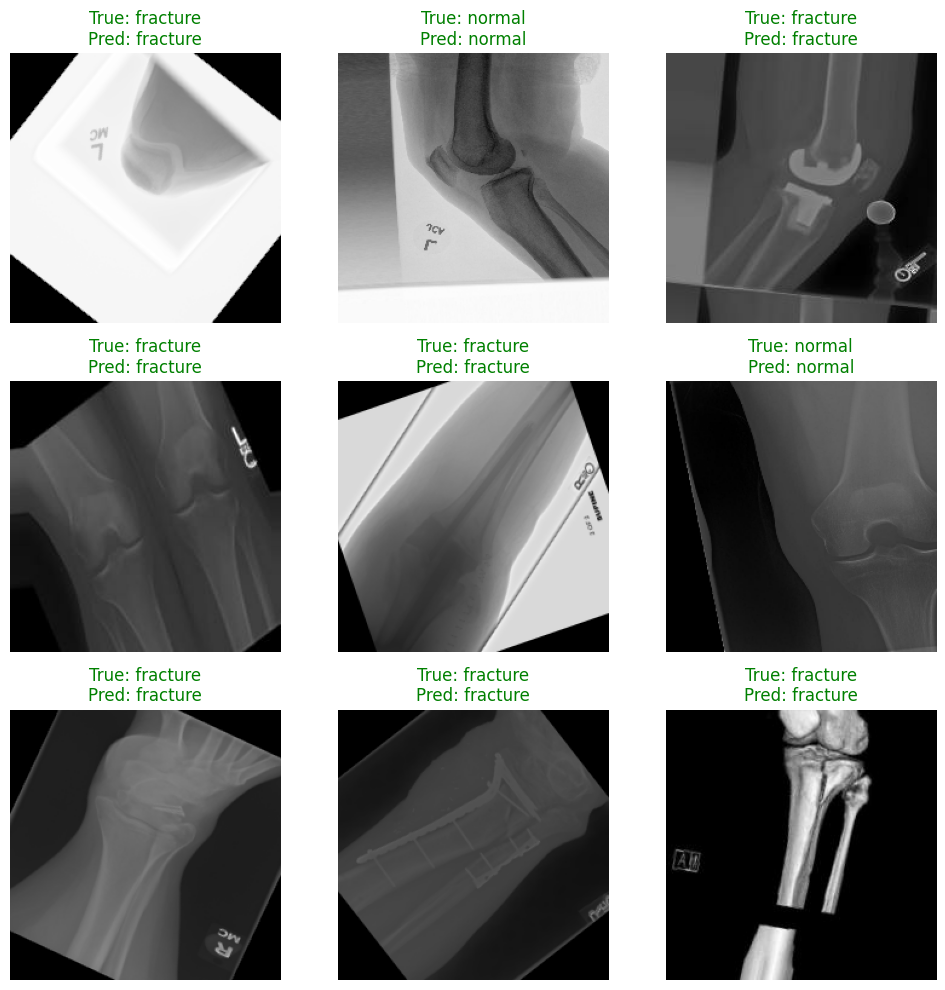

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of images from the test set
image_batch, label_batch = test_ds.as_numpy_iterator().next()
# Make predictions
predictions = model.predict_on_batch(image_batch)

# Convert probabilities to class names
predicted_classes = (predictions > 0.5).astype(int)

# Show the images, their true labels, and the predicted labels
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].astype("uint8"))

    true_label_index = int(label_batch[i])
    predicted_label_index = predicted_classes[i][0]

    true_label = class_names[true_label_index]
    predicted_label = class_names[predicted_label_index]

    # Set title color to green for correct prediction, red for incorrect
    title_color = 'green' if predicted_label == true_label else 'red'

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)
    plt.axis("off")
plt.tight_layout()
plt.show()

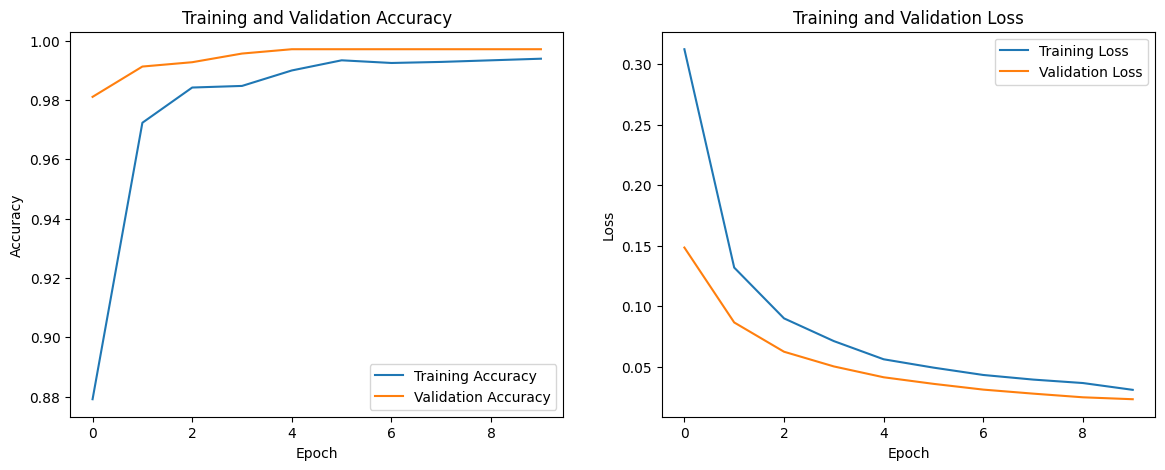

In [ ]:
import matplotlib.pyplot as plt

# The 'history' object is created from the model.fit() command
# For example: history = model.fit(...)

# --- Ensure you have a valid 'history' object before running this ---

# Extracting data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Create the plots
plt.figure(figsize=(14, 5))

# Plot for Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot for Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [ ]:
# The 'model' variable is your trained EfficientNetB0 model
model.save('EfficientNetB0_model.h5')

print("Model saved successfully as 'EfficientNetB0_model.h5'")

Model saved successfully as 'EfficientNetB0_model.h5'
